# **Environment Setup: Install Java and Apache Spark for Big Data Processing** #



In [2]:
!apt-get update -qq
!apt-get install openjdk-11-jdk-headless -qq
!wget -q https://archive.apache.org/dist/spark/spark-3.4.1/spark-3.4.1-bin-hadoop3.tgz
!tar xf spark-3.4.1-bin-hadoop3.tgz
!pip install -q findspark

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package openjdk-11-jre-headless:amd64.
(Reading database ... 117540 files and directories currently installed.)
Preparing to unpack .../openjdk-11-jre-headless_11.0.30+7-1ubuntu1~22.04_amd64.deb ...
Unpacking openjdk-11-jre-headless:amd64 (11.0.30+7-1ubuntu1~22.04) ...
Selecting previously unselected package openjdk-11-jdk-headless:amd64.
Preparing to unpack .../openjdk-11-jdk-headless_11.0.30+7-1ubuntu1~22.04_amd64.deb ...
Unpacking openjdk-11-jdk-headless:amd64 (11.0.30+7-1ubuntu1~22.04) ...
Setting up openjdk-11-jre-headless:amd64 (11.0.30+7-1ubuntu1~22.04) ...
update-alternatives: using /usr/lib/jvm/java-11-openjdk-amd64/bin/jjs to provide /usr/bin/jjs (jjs) in auto mode
update-alternatives: using /usr/lib/jvm/java-11-openjdk-amd64/bin/rmid to provide /usr/bin/rmid

# **Configure Spark Environment Variables and Initialize Spark**

In [3]:
import os
import findspark

os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.4.1-bin-hadoop3"

findspark.init()

# **Create Spark Session for Distributed Data Processing**

In [4]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Ecommerce Big Data Project") \
    .getOrCreate()

spark

# **Verify Uploaded Files and Dataset Availability**

In [16]:
!ls /content



 online_retail.csv     spark-3.4.1-bin-hadoop3
'Online Retail.xlsx'   spark-3.4.1-bin-hadoop3.tgz
 online+retail.zip     spark-3.4.1-bin-hadoop3.tgz.1
 sample_data


# **Convert Excel Dataset to CSV Format for Spark Compatibility**

In [15]:
import pandas as pd

# قراءة ملف Excel
df_excel = pd.read_excel("/content/Online Retail.xlsx")

# حفظه كـ CSV
df_excel.to_csv("/content/online_retail.csv", index=False)

print("Conversion Done ✅")

Conversion Done ✅


# **Data Ingestion: Load E-commerce Dataset into Spark DataFrame**

In [17]:
df = spark.read.csv(
    "/content/online_retail.csv",
    header=True,
    inferSchema=True
)

df.show(5)

+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+
|InvoiceNo|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+
|   536365|   85123A|WHITE HANGING HEA...|       6|2010-12-01 08:26:00|     2.55|   17850.0|United Kingdom|
|   536365|    71053| WHITE METAL LANTERN|       6|2010-12-01 08:26:00|     3.39|   17850.0|United Kingdom|
|   536365|   84406B|CREAM CUPID HEART...|       8|2010-12-01 08:26:00|     2.75|   17850.0|United Kingdom|
|   536365|   84029G|KNITTED UNION FLA...|       6|2010-12-01 08:26:00|     3.39|   17850.0|United Kingdom|
|   536365|   84029E|RED WOOLLY HOTTIE...|       6|2010-12-01 08:26:00|     3.39|   17850.0|United Kingdom|
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+
only showing top 5 rows



# **Data Exploration: Inspect Data Schema and Column Data Types**

In [18]:
df.printSchema()

root
 |-- InvoiceNo: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: timestamp (nullable = true)
 |-- UnitPrice: double (nullable = true)
 |-- CustomerID: double (nullable = true)
 |-- Country: string (nullable = true)



# **Dataset Size Analysis: Count Total Number of Records**

In [19]:
df.count()

541909

# **Data Quality Assessment: Check Missing Values in Each Column**

In [20]:
from pyspark.sql.functions import col, count, when

df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df.columns
]).show()

+---------+---------+-----------+--------+-----------+---------+----------+-------+
|InvoiceNo|StockCode|Description|Quantity|InvoiceDate|UnitPrice|CustomerID|Country|
+---------+---------+-----------+--------+-----------+---------+----------+-------+
|        0|        0|       1454|       0|          0|        0|    135080|      0|
+---------+---------+-----------+--------+-----------+---------+----------+-------+



# **Data Cleaning Step 1: Remove Transactions Without CustomerID**

In [21]:
df_clean = df.filter(col("CustomerID").isNotNull())

df_clean.count()

406829

# **Data Cleaning Step 2: Remove Negative Quantities (Exclude Returns)**

In [22]:
df_clean = df_clean.filter(col("Quantity") > 0)

df_clean.count()

397924

# **Data Cleaning Step 3: Remove Zero-Priced Transactions**

In [23]:
df_clean = df_clean.filter(col("UnitPrice") > 0)

df_clean.count()

397884

# **Feature Engineering: Create TotalPrice Column (Quantity × UnitPrice)**

In [24]:
from pyspark.sql.functions import col

df_clean = df_clean.withColumn(
    "TotalPrice",
    col("Quantity") * col("UnitPrice")
)

df_clean.select("Quantity", "UnitPrice", "TotalPrice").show(5)

+--------+---------+------------------+
|Quantity|UnitPrice|        TotalPrice|
+--------+---------+------------------+
|       6|     2.55|15.299999999999999|
|       6|     3.39|             20.34|
|       8|     2.75|              22.0|
|       6|     3.39|             20.34|
|       6|     3.39|             20.34|
+--------+---------+------------------+
only showing top 5 rows



# **Business KPI Calculation: Compute Total Company Revenue**

In [25]:
from pyspark.sql.functions import sum

total_sales = df_clean.agg(
    sum("TotalPrice").alias("TotalRevenue")
)

total_sales.show()

+-----------------+
|     TotalRevenue|
+-----------------+
|8911407.904001074|
+-----------------+



# **Market Analysis: Revenue Distribution by Country**

In [26]:
sales_by_country = df_clean.groupBy("Country") \
    .agg(sum("TotalPrice").alias("Revenue")) \
    .orderBy(col("Revenue").desc())

sales_by_country.show(10)

+--------------+------------------+
|       Country|           Revenue|
+--------------+------------------+
|United Kingdom| 7308391.554000224|
|   Netherlands| 285446.3399999992|
|          EIRE|265545.89999999915|
|       Germany|228867.14000000025|
|        France|209024.05000000025|
|     Australia|138521.30999999976|
|         Spain| 61577.11000000017|
|   Switzerland| 56443.95000000007|
|       Belgium| 41196.34000000001|
|        Sweden| 38378.32999999999|
+--------------+------------------+
only showing top 10 rows



# **Product Performance Analysis: Identify Top Revenue-Generating Products**

In [27]:
top_products = df_clean.groupBy("Description") \
    .agg(sum("TotalPrice").alias("Revenue")) \
    .orderBy(col("Revenue").desc())

top_products.show(10, truncate=False)

+----------------------------------+------------------+
|Description                       |Revenue           |
+----------------------------------+------------------+
|PAPER CRAFT , LITTLE BIRDIE       |168469.6          |
|REGENCY CAKESTAND 3 TIER          |142592.94999999966|
|WHITE HANGING HEART T-LIGHT HOLDER|100448.14999999953|
|JUMBO BAG RED RETROSPOT           |85220.78000000052 |
|MEDIUM CERAMIC TOP STORAGE JAR    |81416.72999999998 |
|POSTAGE                           |77803.95999999999 |
|PARTY BUNTING                     |68844.33000000005 |
|ASSORTED COLOUR BIRD ORNAMENT     |56580.34000000048 |
|Manual                            |53779.93000000001 |
|RABBIT NIGHT LIGHT                |51346.199999999975|
+----------------------------------+------------------+
only showing top 10 rows



# **Data Refinement: Exclude Non-Product Entries (POSTAGE & Manual)**

In [28]:
df_products = df_clean.filter(
    (col("Description") != "POSTAGE") &
    (col("Description") != "Manual")
)

top_products_clean = df_products.groupBy("Description") \
    .agg(sum("TotalPrice").alias("Revenue")) \
    .orderBy(col("Revenue").desc())

top_products_clean.show(10, truncate=False)

+----------------------------------+------------------+
|Description                       |Revenue           |
+----------------------------------+------------------+
|PAPER CRAFT , LITTLE BIRDIE       |168469.6          |
|REGENCY CAKESTAND 3 TIER          |142592.94999999966|
|WHITE HANGING HEART T-LIGHT HOLDER|100448.14999999953|
|JUMBO BAG RED RETROSPOT           |85220.78000000052 |
|MEDIUM CERAMIC TOP STORAGE JAR    |81416.72999999998 |
|PARTY BUNTING                     |68844.33000000005 |
|ASSORTED COLOUR BIRD ORNAMENT     |56580.34000000048 |
|RABBIT NIGHT LIGHT                |51346.199999999975|
|CHILLI LIGHTS                     |46286.50999999995 |
|PAPER CHAIN KIT 50'S CHRISTMAS    |42660.8300000002  |
+----------------------------------+------------------+
only showing top 10 rows



# **Customer Value Analysis: Identify Top-Spending Customers**

In [29]:
top_customers = df_clean.groupBy("CustomerID") \
    .agg(sum("TotalPrice").alias("TotalSpent")) \
    .orderBy(col("TotalSpent").desc())

top_customers.show(10)

+----------+------------------+
|CustomerID|        TotalSpent|
+----------+------------------+
|   14646.0| 280206.0199999994|
|   18102.0|259657.29999999996|
|   17450.0|194550.78999999995|
|   16446.0|          168472.5|
|   14911.0|143825.05999999988|
|   12415.0| 124914.5299999998|
|   14156.0|117379.62999999992|
|   17511.0| 91062.37999999989|
|   16029.0| 81024.84000000001|
|   12346.0|           77183.6|
+----------+------------------+
only showing top 10 rows



# **Time Reference Extraction: Determine Latest Transaction Date**

In [30]:
from pyspark.sql.functions import max

df_clean.agg(max("InvoiceDate")).show()

+-------------------+
|   max(InvoiceDate)|
+-------------------+
|2011-12-09 12:50:00|
+-------------------+



# **RFM Model Construction: Calculate Recency, Frequency, and Monetary Metrics**

In [32]:
from pyspark.sql.functions import max

reference_date = df_clean.agg(max("InvoiceDate")).collect()[0][0]
print(reference_date)
from pyspark.sql.functions import datediff, countDistinct, sum, max, lit

rfm = df_clean.groupBy("CustomerID").agg(
    datediff(
        lit(reference_date),
        max("InvoiceDate")
    ).alias("Recency"),

    countDistinct("InvoiceNo").alias("Frequency"),

    sum("TotalPrice").alias("Monetary")
)

rfm.show(5)

2011-12-09 12:50:00
+----------+-------+---------+------------------+
|CustomerID|Recency|Frequency|          Monetary|
+----------+-------+---------+------------------+
|   13094.0|     21|       12|1927.3200000000002|
|   13973.0|    287|        1|             264.7|
|   17884.0|      3|        4|            717.45|
|   13533.0|    182|        3|270.78999999999996|
|   13918.0|     49|        2|           1212.84|
+----------+-------+---------+------------------+
only showing top 5 rows



# **Statistical Segmentation: Compute Quartiles for RFM Scoring**

In [33]:
quantiles = rfm.approxQuantile(
    ["Recency", "Frequency", "Monetary"],
    [0.25, 0.5, 0.75],
    0.05
)

print(quantiles)

[[19.0, 50.0, 119.0], [1.0, 2.0, 4.0], [319.0199999999999, 671.96, 1447.3899999999999]]


# **RFM Scoring Model: Assign R, F, and M Scores Based on Quartiles**

In [34]:
from pyspark.sql.functions import when

# Recency Score (العكس: الأقل أفضل)
rfm_scored = rfm \
    .withColumn("R_Score",
        when(col("Recency") <= 19, 4)
        .when(col("Recency") <= 50, 3)
        .when(col("Recency") <= 119, 2)
        .otherwise(1)
    ) \
    .withColumn("F_Score",
        when(col("Frequency") >= 4, 4)
        .when(col("Frequency") >= 2, 3)
        .when(col("Frequency") >= 1, 2)
        .otherwise(1)
    ) \
    .withColumn("M_Score",
        when(col("Monetary") >= 1447, 4)
        .when(col("Monetary") >= 672, 3)
        .when(col("Monetary") >= 319, 2)
        .otherwise(1)
    )

rfm_scored.select("CustomerID","R_Score","F_Score","M_Score").show(5)

+----------+-------+-------+-------+
|CustomerID|R_Score|F_Score|M_Score|
+----------+-------+-------+-------+
|   13094.0|      3|      4|      4|
|   13973.0|      1|      2|      1|
|   17884.0|      4|      4|      3|
|   13533.0|      1|      3|      1|
|   13918.0|      3|      3|      3|
+----------+-------+-------+-------+
only showing top 5 rows



# **Customer Segmentation: Generate RFM Score and Classify Customers**

In [35]:
from pyspark.sql.functions import concat

rfm_scored = rfm_scored.withColumn(
    "RFM_Score",
    concat(col("R_Score"), col("F_Score"), col("M_Score"))
)

rfm_scored.select("CustomerID","RFM_Score").show(5)

rfm_segmented = rfm_scored.withColumn(
    "Segment",
    when(col("RFM_Score") == "444", "Champions")
    .when(col("R_Score") >= 3, "Loyal Customers")
    .when(col("R_Score") == 1, "At Risk")
    .otherwise("Potential")
)

rfm_segmented.select("CustomerID","RFM_Score","Segment").show(10)

+----------+---------+
|CustomerID|RFM_Score|
+----------+---------+
|   13094.0|      344|
|   13973.0|      121|
|   17884.0|      443|
|   13533.0|      131|
|   13918.0|      333|
+----------+---------+
only showing top 5 rows

+----------+---------+---------------+
|CustomerID|RFM_Score|        Segment|
+----------+---------+---------------+
|   13094.0|      344|Loyal Customers|
|   13973.0|      121|        At Risk|
|   17884.0|      443|Loyal Customers|
|   13533.0|      131|        At Risk|
|   13918.0|      333|Loyal Customers|
|   17267.0|      131|        At Risk|
|   14768.0|      431|Loyal Customers|
|   15776.0|      121|        At Risk|
|   13956.0|      443|Loyal Customers|
|   14473.0|      231|      Potential|
+----------+---------+---------------+
only showing top 10 rows



# **Segment Distribution Analysis: Count Customers per Segment**

In [36]:
segment_distribution = rfm_segmented.groupBy("Segment") \
    .count() \
    .orderBy(col("count").desc())

segment_distribution.show()

+---------------+-----+
|        Segment|count|
+---------------+-----+
|Loyal Customers| 1580|
|        At Risk| 1220|
|      Potential|  942|
|      Champions|  596|
+---------------+-----+



# **Revenue Contribution Analysis: Calculate Revenue by Customer Segment**

In [37]:
segment_revenue = rfm_segmented.groupBy("Segment") \
    .agg(sum("Monetary").alias("TotalRevenue")) \
    .orderBy(col("TotalRevenue").desc())

segment_revenue.show()

+---------------+------------------+
|        Segment|      TotalRevenue|
+---------------+------------------+
|      Champions|        4716443.36|
|Loyal Customers|2374887.6709999987|
|      Potential| 999733.1719999993|
|        At Risk| 820343.7010000008|
+---------------+------------------+



# **Data Visualization: Customer Distribution by Segment**

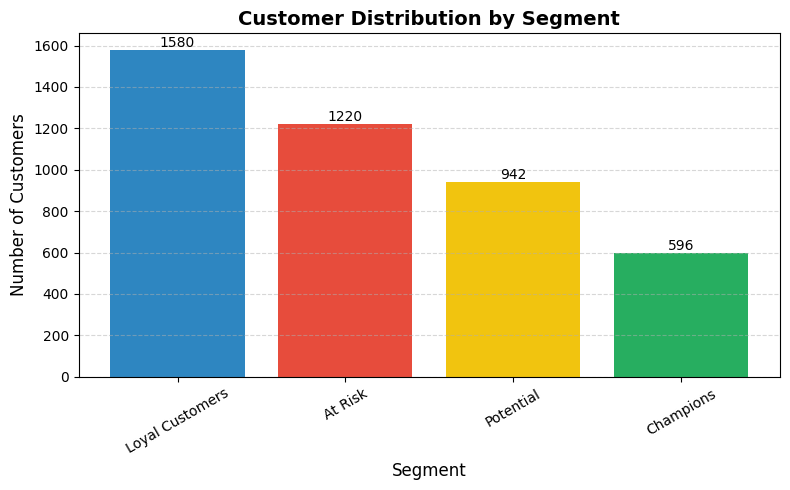

In [41]:
import matplotlib.pyplot as plt

segment_pd = segment_distribution.toPandas()

plt.figure(figsize=(8,5))

bars = plt.bar(
    segment_pd["Segment"],
    segment_pd["count"],
    color=["#2E86C1","#E74C3C","#F1C40F","#27AE60"]
)

plt.title("Customer Distribution by Segment", fontsize=14, fontweight='bold')
plt.xlabel("Segment", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)
plt.xticks(rotation=30)

# إضافة الأرقام فوق الأعمدة
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom'
    )

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# **Revenue Visualization: Revenue Contribution by Segment (Millions)**

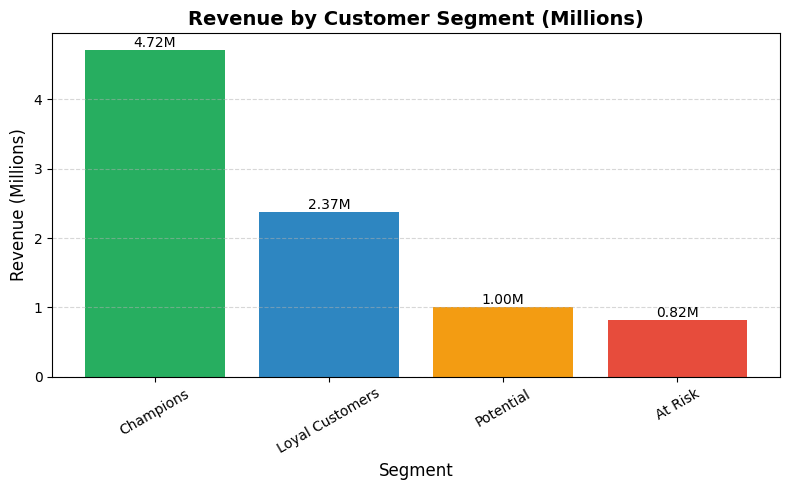

In [42]:
segment_rev_pd = segment_revenue.toPandas()

plt.figure(figsize=(8,5))

bars = plt.bar(
    segment_rev_pd["Segment"],
    segment_rev_pd["TotalRevenue"]/1_000_000,
    color=["#27AE60","#2E86C1","#F39C12","#E74C3C"]
)

plt.title("Revenue by Customer Segment (Millions)", fontsize=14, fontweight='bold')
plt.xlabel("Segment", fontsize=12)
plt.ylabel("Revenue (Millions)", fontsize=12)
plt.xticks(rotation=30)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.2f}M',
        ha='center',
        va='bottom'
    )

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# **Product Visualization: Top 10 Revenue-Generating Products**

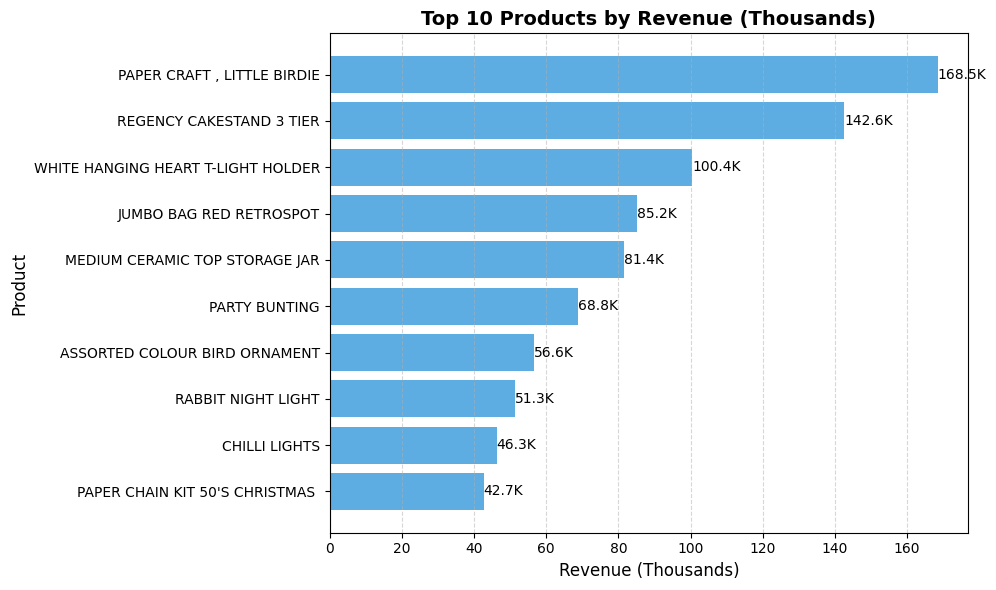

In [43]:
top_products_pd = top_products_clean.limit(10).toPandas()

plt.figure(figsize=(10,6))

bars = plt.barh(
    top_products_pd["Description"],
    top_products_pd["Revenue"]/1000,
    color="#5DADE2"
)

plt.title("Top 10 Products by Revenue (Thousands)", fontsize=14, fontweight='bold')
plt.xlabel("Revenue (Thousands)", fontsize=12)
plt.ylabel("Product", fontsize=12)

plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f'{width:.1f}K',
        va='center'
    )

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()